In [2]:
from sql.game import Game
import numpy as np
import pandas as pd
import statsmodels.api as sm

In [3]:
from sql.session import session
from sqlalchemy import select

results = session.execute(select(Game)).scalars().all()


df = pd.DataFrame([g.__dict__ for g in results]).set_index("name")

df = df.dropna(subset=["rank_all"])

In [4]:
def keep(col: str) -> bool:
    if "_sa_" in col:
        return False
    if col in {"thumbnail", "image", "description", "url", "wanting", "id", "trading", "owned", "wishing", "usersrated"}:
        return False
    if "num" in col:
        return False
    if "rank" in col:
        return False
    if col in ["min_play_time", "max_play_time", "min_players", "max_players"]: #colinearity with playing_time
        return False
    if col in ["average", "median", "stddev", "const"]:
        return False
    return True

columns_to_keep = [col for col in df if keep(col)]
df = df[df["usersrated"] > 1000]
df = df[df["year_published"] >= 1950]
df = df[columns_to_keep]
df = df[df["bayesaverage"] > 0.1]
df = df[df["averageweight"] > 0.0]
print(columns_to_keep, set(df) - set(columns_to_keep))

['playing_time', 'averageweight', 'year_published', 'min_age', 'best_player_count', 'language_dependence', 'bayesaverage', 'recommended_player_counts'] set()


In [5]:
from exploration.utils import add_player_group_features, add_best_player_count_features, decode_language_dependence

df = add_player_group_features(df, "recommended_player_counts")
df = df[df["recommended_for_valid"]==1].drop(columns=["recommended_for_valid", "recommended_player_counts", "best_player_count"])

In [6]:
# df = add_best_player_count_features(df, "best_player_count")
# df = df[df["best_player_count_valid"]==1].drop(columns=["best_player_count_valid", "best_player_count"])

In [7]:
df.language_dependence = df.language_dependence.apply(decode_language_dependence)

In [8]:
# Drop remaining missing values
df = df.dropna()

X = df[[col for col in df if "rating" not in col and "rank" not in col]]
X = (X - X.min()) / (X.max() - X.min()).replace(0, 1)

y = X.pop("bayesaverage") * 0.1

X = sm.add_constant(X)

In [9]:
X.dtypes

const                               float64
playing_time                        float64
averageweight                       float64
year_published                      float64
min_age                             float64
language_dependence                 float64
recommended_for_solo                float64
recommended_for_duo                 float64
recommended_for_small_group         float64
recommended_for_large_group         float64
recommended_for_very_large_group    float64
recommended_for_even                float64
recommended_for_odd                 float64
dtype: object

In [10]:
model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           bayesaverage   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     113.5
Date:                Tue, 24 Feb 2026   Prob (F-statistic):          2.50e-242
Time:                        21:47:53   Log-Likelihood:                 11777.
No. Observations:                3833   AIC:                        -2.353e+04
Df Residuals:                    3820   BIC:                        -2.345e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

In [11]:
import matplotlib.pyplot as plt

EARTH = {
    "line": "#8B5E3C",        # warm brown
    "density": "#6B8E23",     # olive green
    "accent": "#A3B18A",      # muted sage
    "zero": "#444444"
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#444444",
    "axes.labelcolor": "#444444",
    "xtick.color": "#444444",
    "ytick.color": "#444444",
    "font.size": 11,
})

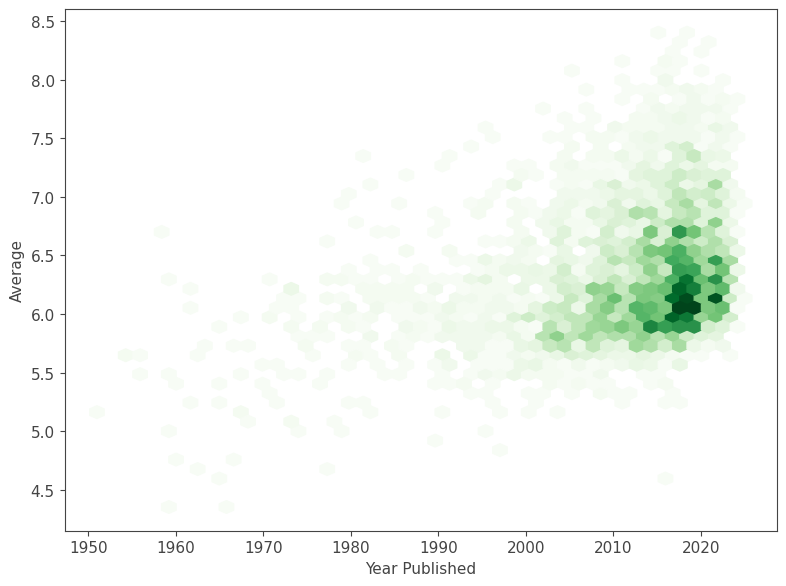

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Clean data
plot_df = df[["year_published", "bayesaverage"]].dropna()

x = plot_df["year_published"]
y = plot_df["bayesaverage"]

plt.figure(figsize=(8, 6))

# Earth-toned hexbin
plt.hexbin(
    x,
    y,
    gridsize=45,
    cmap="Greens",
    mincnt=1
)

# Regression line (using full model)
x_vals = np.linspace(x.min(), x.max(), 100)

model_columns = results.model.exog_names
predictor_columns = [c for c in model_columns if c != "const"]

# Build prediction frame from df
X_line = pd.DataFrame({
    col: df[col].mean() for col in predictor_columns
}, index=range(100))

X_line["averageweight"] = x_vals

if "const" in model_columns:
    X_line = sm.add_constant(X_line, has_constant="add")

y_line = results.predict(X_line)

# plt.plot(x_vals, y_line, color=EARTH["line"], linewidth=2)

plt.xlabel("Year Published")
plt.ylabel("Average")
plt.tight_layout()
plt.show()

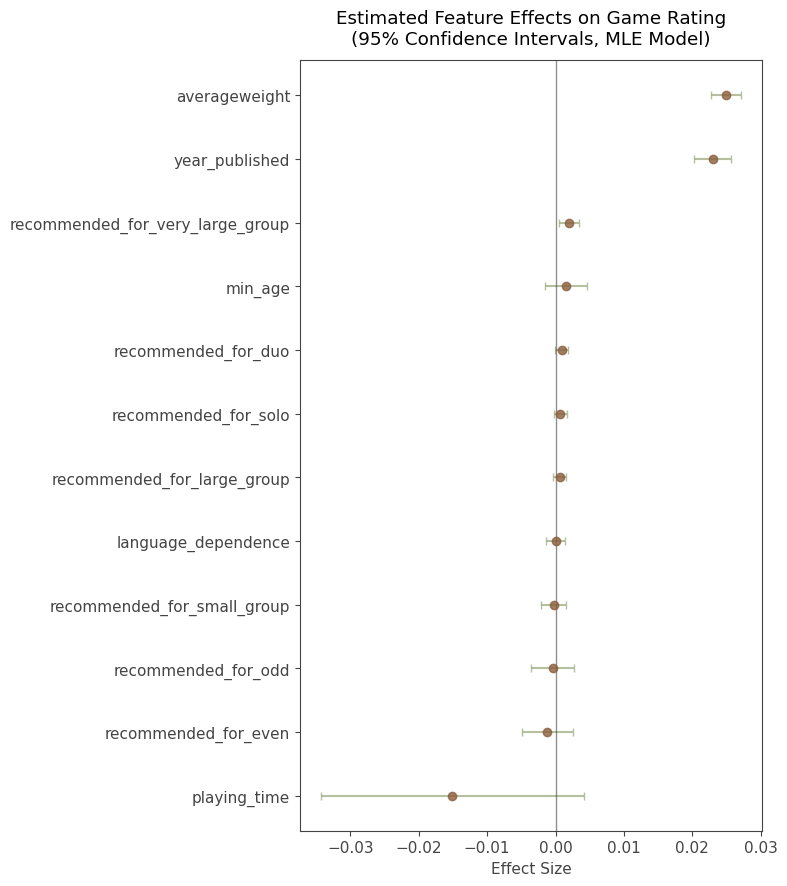

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

params = results.params
conf = results.conf_int()

coef_df = pd.DataFrame({
    "coef": params,
    "lower": conf[0],
    "upper": conf[1]
})

coef_df = coef_df.drop(index="const", errors="ignore")
coef_df = coef_df.sort_values("coef")

plt.figure(figsize=(8, 9))

plt.errorbar(
    coef_df["coef"],
    coef_df.index,
    xerr=[
        coef_df["coef"] - coef_df["lower"],
        coef_df["upper"] - coef_df["coef"]
    ],
    fmt="o",
    color="#8B5E3C",      # earthy brown (fainter feel)
    ecolor="#A3B18A",     # muted sage
    elinewidth=1.5,
    capsize=3,
    alpha=0.8              # 👈 slightly softened
)

# Zero reference line (subtle)
plt.axvline(0, color="#444444", linewidth=1, alpha=0.6)

# Clean title
plt.title(
    "Estimated Feature Effects on Game Rating\n"
    "(95% Confidence Intervals, MLE Model)",
    pad=12
)

plt.xlabel("Effect Size")
plt.ylabel("")

plt.tight_layout()
plt.savefig("ols_residuals.png")
plt.show()


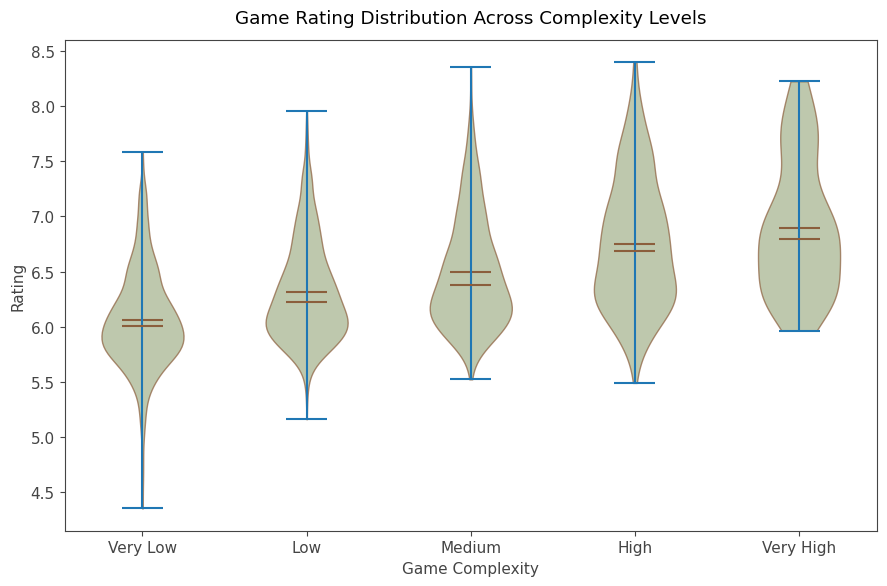

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure we have needed columns
plot_df = pd.concat([X, y], axis=1).dropna()

# Define 5 complexity bins (equal-width)
plot_df["complexity_bin"] = pd.cut(
    plot_df["averageweight"],
    bins=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

# Prepare data for violin plot
categories = plot_df["complexity_bin"].cat.categories

grouped = [
    plot_df.loc[plot_df["complexity_bin"] == label, "bayesaverage"].dropna()
    for label in categories
]

# Create figure
plt.figure(figsize=(9, 6))

parts = plt.violinplot(
    grouped,
    showmeans=True,
    showmedians=True
)

# Style violins to match your original theme
for body in parts["bodies"]:
    body.set_facecolor("#A3B18A")
    body.set_edgecolor("#8B5E3C")
    body.set_alpha(0.7)

if "cmeans" in parts:
    parts["cmeans"].set_color("#8B5E3C")

if "cmedians" in parts:
    parts["cmedians"].set_color("#8B5E3C")

# Axis labels
plt.xticks(range(1, 6), categories)

plt.title(
    "Game Rating Distribution Across Complexity Levels",
    pad=12
)

plt.ylabel("Rating")
plt.xlabel("Game Complexity")

plt.tight_layout()
plt.savefig("pre_violin.png")
plt.show()


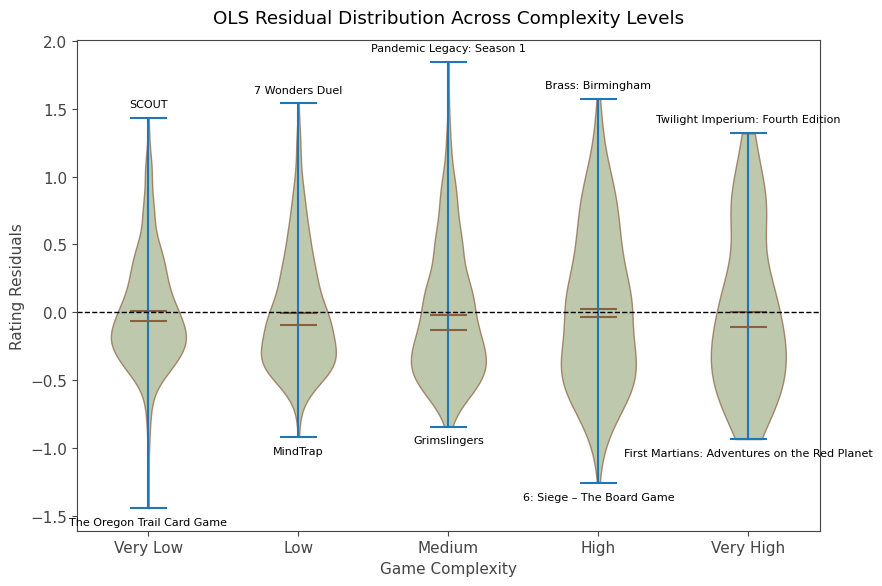

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Ensure we have needed columns
plot_df = pd.concat([X, y], axis=1).dropna()

# Add intercept if not already included
if "const" not in plot_df.columns:
    X_with_const = sm.add_constant(plot_df[X.columns])
else:
    X_with_const = plot_df[X.columns]

# Fit OLS model
model = sm.OLS(plot_df[y.name], X_with_const).fit()

# Compute residuals
plot_df["residuals"] = model.resid

# Define 5 complexity bins (equal-width)
plot_df["complexity_bin"] = pd.cut(
    plot_df["averageweight"],
    bins=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

# Prepare data for violin plot
categories = plot_df["complexity_bin"].cat.categories

grouped = [
    plot_df.loc[plot_df["complexity_bin"] == label, "residuals"].dropna()
    for label in categories
]

# Create figure
plt.figure(figsize=(9, 6))

parts = plt.violinplot(
    grouped,
    showmeans=True,
    showmedians=True
)

# Style violins
for body in parts["bodies"]:
    body.set_facecolor("#A3B18A")
    body.set_edgecolor("#8B5E3C")
    body.set_alpha(0.7)

if "cmeans" in parts:
    parts["cmeans"].set_color("#8B5E3C")
if "cmedians" in parts:
    parts["cmedians"].set_color("#8B5E3C")

plt.xticks(range(1, 6), categories)
plt.axhline(0, color="black", linestyle="--", linewidth=1)

# --- Label min and max residual per bin ---
y_range = plot_df["residuals"].max() - plot_df["residuals"].min()
offset = 0.02 * y_range  # 2% of total vertical range

for i, label in enumerate(categories):
    subset = plot_df[plot_df["complexity_bin"] == label]

    if subset.empty:
        continue

    # Max residual in bin
    max_row = subset.loc[subset["residuals"].idxmax()]
    # Min residual in bin
    min_row = subset.loc[subset["residuals"].idxmin()]

    x_pos = i + 1

    # Annotate max (slightly above)
    plt.text(
        x=x_pos,
        y=max_row["residuals"] + offset,
        s=str(max_row.name),
        fontsize=8,
        ha="center",
        va="bottom"
    )

    # Annotate min (slightly below)
    plt.text(
        x=x_pos,
        y=min_row["residuals"] - offset,
        s=str(min_row.name),
        fontsize=8,
        ha="center",
        va="top"
    )

plt.title(
    "OLS Residual Distribution Across Complexity Levels",
    pad=12
)

plt.ylabel("Rating Residuals")
plt.xlabel("Game Complexity")

plt.tight_layout()
plt.savefig("residual_violin.png")
plt.show()


In [16]:
len(X)

3833